In [1]:
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)
%cd gdrive/My Drive/571Tproject/

Mounted at /content/gdrive
/content/gdrive/My Drive/571Tproject


# meta 

In [2]:
import torch
from torchvision import datasets,transforms,models
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])
train_set = datasets.CIFAR10('./datasets', train=True, 
                                         download=True, transform=transform)
test_set = datasets.CIFAR10('./datasets', train=False, 
                                        download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=100, 
                                           shuffle=True, num_workers=2)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=100, 
                                          shuffle=False, num_workers=2)

Files already downloaded and verified
Files already downloaded and verified


In [4]:
def get_accuracy(network, data_loader):
    network.eval()
    iterator = iter(data_loader)    
    correct = 0
    total = 0
    for i in range(len(iterator)):        
        x, y = next(iterator)
        x_gpu = x.to('cuda')
        y_gpu = y.to('cuda')

        pred_y = network(x_gpu).argmax(dim=1, keepdim=True)                                         
        correct += pred_y.eq(y_gpu.view_as(pred_y)).sum().item()               
        total += pred_y.shape[0]
           
    return correct / total

In [5]:
class LeNet(nn.Module):
    def __init__(self):
      super().__init__()
      self.conv1 = nn.Conv2d(3, 16, 3, 1, padding=1) # input is color image, hence 3 i/p channels. 16 filters, kernal size is tuned to 3 to avoid overfitting, stride is 1 , padding is 1 extract all edge features.
      self.conv2 = nn.Conv2d(16, 32, 3, 1, padding=1) # We double the feature maps for every conv layer as in pratice it is really good.
      self.conv3 = nn.Conv2d(32, 64, 3, 1, padding=1)
      self.fc1 = nn.Linear(4*4*64, 500) # I/p image size is 32*32, after 3 MaxPooling layers it reduces to 4*4 and 64 because our last conv layer has 64 outputs. Output nodes is 500
      self.dropout1 = nn.Dropout(0.5)
      self.fc2 = nn.Linear(500, 10) # output nodes are 10 because our dataset have 10 different categories
    def forward(self, x):
      x = F.relu(self.conv1(x)) #Apply relu to each output of conv layer.
      x = F.max_pool2d(x, 2, 2) # Max pooling layer with kernal of 2 and stride of 2
      x = F.relu(self.conv2(x))
      x = F.max_pool2d(x, 2, 2)
      x = F.relu(self.conv3(x))
      x = F.max_pool2d(x, 2, 2)
      x = x.view(-1, 4*4*64) # flatten our images to 1D to input it to the fully connected layers
      x = F.relu(self.fc1(x))
      x = self.dropout1(x) # Applying dropout b/t layers which exchange highest parameters. This is a good practice
      x = self.fc2(x)
      return x

In [6]:
class ResNetModel(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.resnet = models.resnet18(pretrained=True)
        
        num_ftrs = self.resnet.fc.in_features
        self.resnet.fc = nn.Linear(num_ftrs, num_classes)
    
    def forward(self, x):
        x = self.resnet(x)
        return x

In [7]:
network1 = LeNet().to('cuda') # run our model on cuda GPU for faster results
network4 = ResNetModel().to('cuda') # run our model on cuda GPU for faster results

/usr/local/lib/python3.9/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.9/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 112MB/s]


In [8]:
network2 = torch.hub.load('pytorch/vision:v0.10.0', 'alexnet', pretrained=True).to('cuda')
network2.classifier[4] = nn.Linear(4096,1024)
network2.classifier[6] = nn.Linear(1024,10)
network2.to('cuda')

Downloading: "https://github.com/pytorch/vision/zipball/v0.10.0" to /root/.cache/torch/hub/v0.10.0.zip
/usr/local/lib/python3.9/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth
100%|██████████| 233M/233M [00:02<00:00, 117MB/s]


AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [9]:
network3 = models.vgg16(weights = models.VGG16_Weights.IMAGENET1K_V1)
network3.classifier[4] = nn.Linear(4096,1024)
network3.classifier[6] = nn.Linear(1024,10)
network3.to('cuda')

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:02<00:00, 190MB/s]


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [10]:
state_dict1 = torch.load('pretrained_models/network1.pt')
state_dict2 = torch.load('pretrained_models/network2.pt')
state_dict3 = torch.load('pretrained_models/network3.pt')
state_dict4 = torch.load('pretrained_models/network4.pt')

network1.load_state_dict(state_dict1)
network2.load_state_dict(state_dict2)
network3.load_state_dict(state_dict3)
network4.load_state_dict(state_dict4)

<All keys matched successfully>

In [ ]:
get_accuracy(network1,test_loader)

0.7453

In [ ]:
get_accuracy2(network2,test_loader)

/usr/local/lib/python3.9/dist-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


0.7995

In [ ]:
get_accuracy3(network3,test_loader)

/usr/local/lib/python3.9/dist-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


0.8636

In [ ]:
get_accuracy(network4,test_loader)

0.8141

In [ ]:
def get_accuracy2(network, data_loader):
    network.eval()
    iterator = iter(data_loader)    
    correct = 0
    total = 0
    for i in range(len(iterator)):        
        x, y = next(iterator)
        x = transforms.Resize(256)(x)
        x_gpu = x.to('cuda')
        y_gpu = y.to('cuda')

        pred_y = network(x_gpu).argmax(dim=1, keepdim=True)                                         
        correct += pred_y.eq(y_gpu.view_as(pred_y)).sum().item()               
        total += pred_y.shape[0]
           
    return correct / total

In [ ]:
def get_accuracy3(network, data_loader):
    network.eval()
    iterator = iter(data_loader)    
    correct = 0
    total = 0
    for i in range(len(iterator)):        
        x, y = next(iterator)
        resize = transforms.Resize((224, 224))
        x = resize(x)
        x_gpu = x.to('cuda')
        y_gpu = y.to('cuda')

        pred_y = network(x_gpu).argmax(dim=1, keepdim=True)                                         
        correct += pred_y.eq(y_gpu.view_as(pred_y)).sum().item()               
        total += pred_y.shape[0]
           
    return correct / total

# 新段落

In [16]:
class MetaNet(nn.Module):   
    def __init__(self, modelA, modelB, modelC):
        super().__init__()
        self.modelA = modelA
        self.modelB = modelB
        self.modelC = modelC
        self.classifier = nn.Linear(10 * 3, 10)
        
    def forward(self, x):
        x1 = self.modelA(x)
        resize2 = transforms.Resize(256)
        x2 = self.modelB(resize2(x))
        resize3 = transforms.Resize((224, 224))
        x3 = self.modelC(resize3(x))
        x = torch.cat((x1, x2, x3), dim=1)
        out = self.classifier(x)
        return out
    
network_meta = MetaNet(network1, network4, network2)
for param in network_meta.parameters():
    param.requires_grad = False

for param in network_meta.classifier.parameters():
    param.requires_grad = True 
network_meta.to('cuda')

MetaNet(
  (modelA): LeNet(
    (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fc1): Linear(in_features=1024, out_features=500, bias=True)
    (dropout1): Dropout(p=0.5, inplace=False)
    (fc2): Linear(in_features=500, out_features=10, bias=True)
  )
  (modelB): ResNetModel(
    (resnet): ResNet(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentu

In [17]:
optimizer = torch.optim.Adam(network_meta.parameters(), lr=0.001)
num_epochs = 5
train_losses = []
train_corrects = []
val_losses = []
val_corrects = []
for e in range(num_epochs):
    print('epoch {}:'.format(e+1))

    network_meta.train()
    train_iter = iter(train_loader)
    train_loss = 0
    train_correct = 0
    for i in range(len(train_loader)):        
        x, y = next(train_iter)
        x_gpu = x.to('cuda')
        y_gpu = y.to('cuda')

        pred = network_meta(x_gpu)

        pred_y = pred.argmax(dim=1, keepdim=True)                                 
        train_correct += pred_y.eq(y_gpu.view_as(pred_y)).sum().item()
        loss = nn.CrossEntropyLoss()(pred, y_gpu)        
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_loss = train_loss/len(train_loader)
    train_correct = train_correct/len(train_loader)
    train_losses.append(train_loss)
    train_corrects.append(train_correct)
    print('training loss: {}, accuracy {} '.format(train_loss, train_correct))

    network_meta.eval()
    val_iter = iter(test_loader)
    val_loss = 0
    val_correct = 0    
    for i in range(len(test_loader)):
        x, y = next(val_iter)
        x_gpu = x.to('cuda')
        y_gpu = y.to('cuda')

        pred = network_meta(x_gpu)

        pred_y = pred.argmax(dim=1, keepdim=True)                                         
        val_correct += pred_y.eq(y_gpu.view_as(pred_y)).sum().item()        
        loss = nn.CrossEntropyLoss()(pred, y_gpu)
        val_loss += loss.item()

    val_loss = val_loss/len(test_loader)
    val_correct = val_correct/ len(test_loader)
    val_losses.append(val_loss)
    val_corrects.append(val_correct)
    print('test loss: {}, test accuracy {} '.format(val_loss, val_correct))

epoch 1:


/usr/local/lib/python3.9/dist-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


training loss: 0.9663780111074448, accuracy 70.612 
test loss: 0.6010896801948548, test accuracy 79.97 
epoch 2:
training loss: 0.45055981996655464, accuracy 84.93 
test loss: 0.538649151623249, test accuracy 82.12 
epoch 3:
training loss: 0.4022395445406437, accuracy 86.436 
test loss: 0.5250737679004669, test accuracy 82.44 
epoch 4:
training loss: 0.3863128960132599, accuracy 86.638 
test loss: 0.5224211946129799, test accuracy 82.57 
epoch 5:
training loss: 0.3774961718916893, accuracy 87.116 
test loss: 0.5181743362545967, test accuracy 82.57 


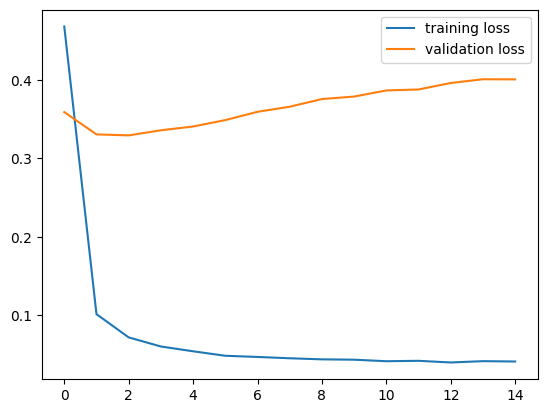

In [ ]:
plt.plot(train_losses, label='training loss')
plt.plot(val_losses, label='validation loss')
plt.legend()

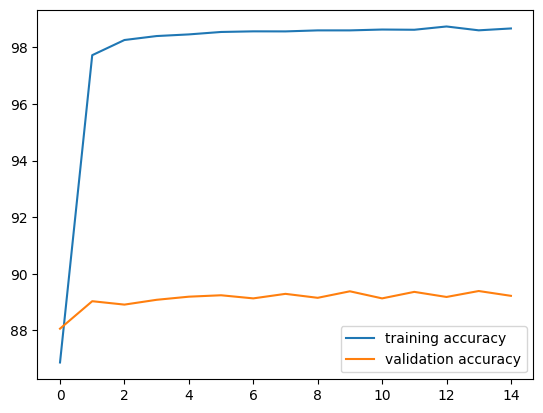

In [ ]:
plt.plot(train_corrects, label='training accuracy')
plt.plot(val_corrects, label='validation accuracy')
plt.legend()